In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
name_path = 'hcm_aqi_full_dataset.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357


In [3]:

import json
# 2. Chuyển DataFrame thành danh sách các Dictionary (Objects)
# Orient='records' chính là định dạng chuẩn mà MongoDB cần
records = df.to_dict(orient='records')

# 3. Xuất ra file JSON mới
with open('hcm_aqi_mongodb_ready.json', 'w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print("Đã tạo xong file hcm_aqi_mongodb_ready.json!")
print("Bro lấy file này import vào MongoDB Compass là ăn ngay 100%.")

Đã tạo xong file hcm_aqi_mongodb_ready.json!
Bro lấy file này import vào MongoDB Compass là ăn ngay 100%.


📊 Đang vẽ Biểu đồ 1: Khí thải xe cộ...


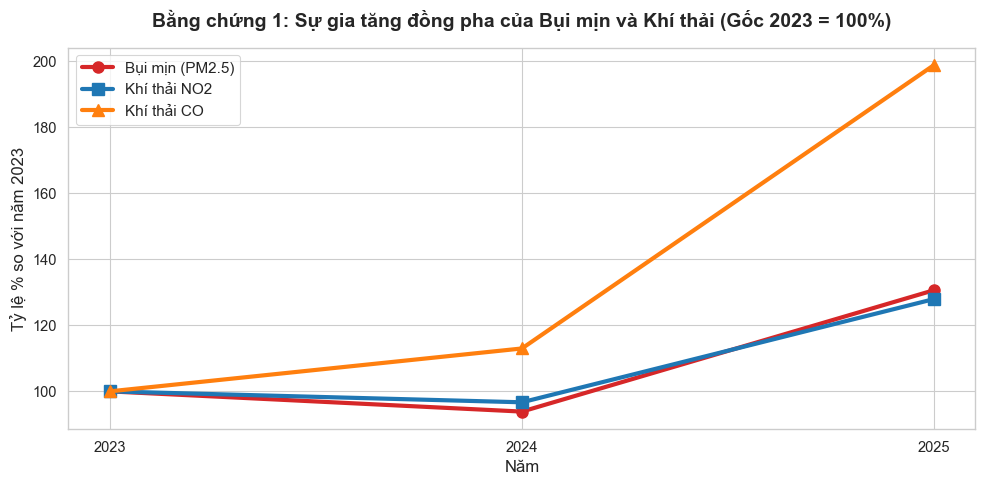

📊 Đang vẽ Biểu đồ 2: Hiệu ứng cuối tuần...


C:\Users\nguye\AppData\Local\Temp\ipykernel_9940\996564820.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2025, x='is_weekend', y='PM2.5', capsize=.1, palette='pastel', edgecolor='black')


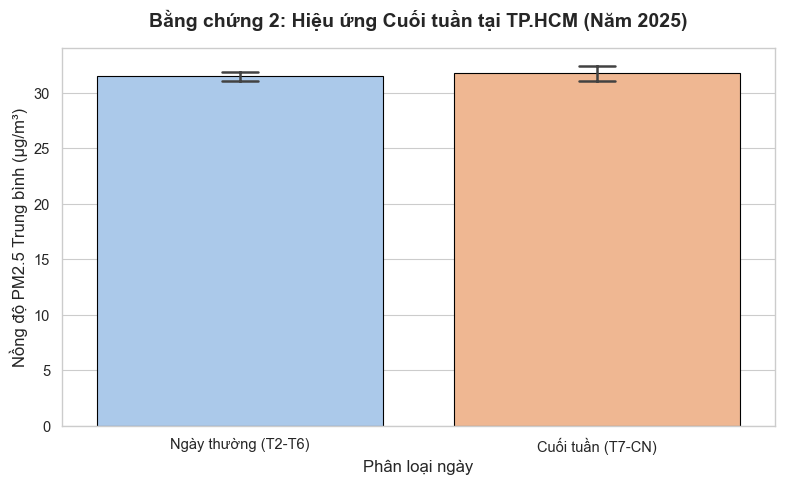

📊 Đang vẽ Biểu đồ 3: Chu kỳ 24h & Đỉnh kẹt xe...


C:\Users\nguye\AppData\Local\Temp\ipykernel_9940\996564820.py:91: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


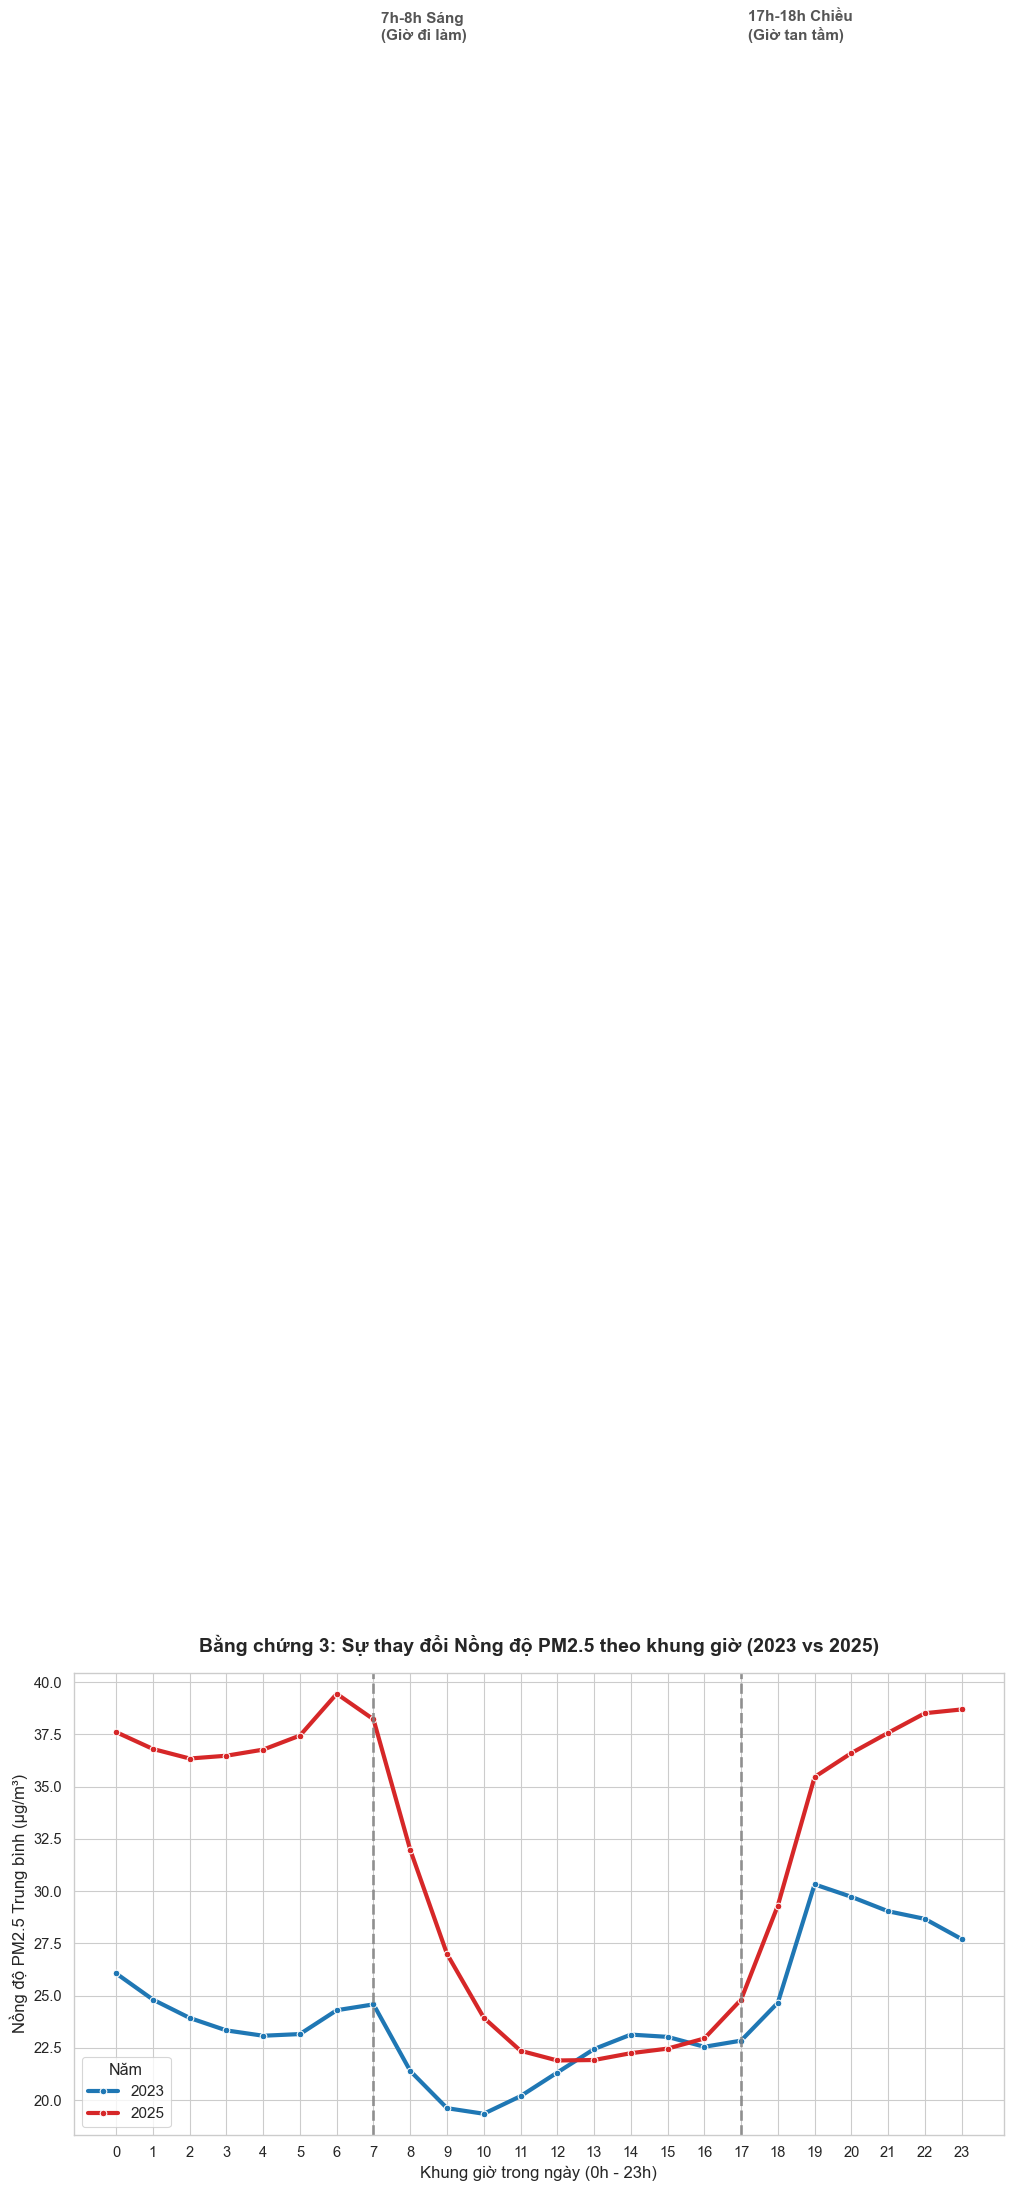

✅ Đã hoàn tất vẽ 3 biểu đồ!


In [7]:

# ==========================================
# CÀI ĐẶT THÔNG SỐ HIỂN THỊ (STYLE)
# ==========================================
# Set style của seaborn cho biểu đồ nhìn "Tây" và chuyên nghiệp hơn để đưa vào Paper
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Tiền xử lý các cột thời gian
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year
df['hour'] = df['time'].dt.hour
df['dayofweek'] = df['time'].dt.dayofweek

# Tạo cột phân loại: Ngày thường (0-4 là T2-T6) vs Cuối tuần (5-6 là T7-CN)
df['is_weekend'] = df['dayofweek'].apply(lambda x: 'Cuối tuần (T7-CN)' if x >= 5 else 'Ngày thường (T2-T6)')

# Chúng ta chỉ tập trung vào 3 năm trọn vẹn: 2023, 2024, 2025
df_clean = df[df['year'].isin([2023, 2024, 2025])].copy()


# ======================================================================
# BIỂU ĐỒ 1: SỰ ĐỒNG PHA CỦA PM2.5 VÀ KHÍ THẢI (NO2, CO)
# ======================================================================
print("📊 Đang vẽ Biểu đồ 1: Khí thải xe cộ...")
plt.figure(figsize=(10, 5))

# Tính trung bình theo năm
yearly_stats = df_clean.groupby('year')[['PM2.5', 'NO2', 'CO']].mean()

# Chuẩn hóa về phần trăm (Lấy năm 2023 làm mốc 100%)
yearly_pct = (yearly_stats / yearly_stats.loc[2023]) * 100

plt.plot(yearly_pct.index, yearly_pct['PM2.5'], marker='o', markersize=8, linewidth=3, label='Bụi mịn (PM2.5)', color='#d62728')
plt.plot(yearly_pct.index, yearly_pct['NO2'], marker='s', markersize=8, linewidth=3, label='Khí thải NO2', color='#1f77b4')
plt.plot(yearly_pct.index, yearly_pct['CO'], marker='^', markersize=8, linewidth=3, label='Khí thải CO', color='#ff7f0e')

plt.title('Bằng chứng 1: Sự gia tăng đồng pha của Bụi mịn và Khí thải (Gốc 2023 = 100%)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Tỷ lệ % so với năm 2023', fontsize=12)
plt.xlabel('Năm', fontsize=12)
plt.xticks([2023, 2024, 2025])
plt.legend(fontsize=11)
plt.tight_layout()
plt.show() # Hiện biểu đồ 1


# ======================================================================
# BIỂU ĐỒ 2: HIỆU ỨNG CUỐI TUẦN (WEEKEND EFFECT) NĂM 2025
# ======================================================================
print("📊 Đang vẽ Biểu đồ 2: Hiệu ứng cuối tuần...")
plt.figure(figsize=(8, 5))

# Chỉ lấy dữ liệu năm 2025 (năm ô nhiễm nhất sau khi làm xong đường)
df_2025 = df_clean[df_clean['year'] == 2025]

# Vẽ barplot với dải sai số (error bar)
sns.barplot(data=df_2025, x='is_weekend', y='PM2.5', capsize=.1, palette='pastel', edgecolor='black')

plt.title('Bằng chứng 2: Hiệu ứng Cuối tuần tại TP.HCM (Năm 2025)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Nồng độ PM2.5 Trung bình (µg/m³)', fontsize=12)
plt.xlabel('Phân loại ngày', fontsize=12)
plt.tight_layout()
plt.show() # Hiện biểu đồ 2


# ======================================================================
# BIỂU ĐỒ 3: ĐỈNH KẸT XE GIỜ CAO ĐIỂM (2023 vs 2025)
# ======================================================================
print("📊 Đang vẽ Biểu đồ 3: Chu kỳ 24h & Đỉnh kẹt xe...")
plt.figure(figsize=(12, 6))

# Chỉ lấy dữ liệu 2 năm để so sánh sự khác biệt trước/sau khi làm đường
df_compare = df_clean[df_clean['year'].isin([2023, 2025])]

# Vẽ lineplot theo 24 giờ
sns.lineplot(data=df_compare, x='hour', y='PM2.5', hue='year', 
             palette=['#1f77b4', '#d62728'], linewidth=3, errorbar=None, marker='o')

# Thêm 2 đường dọc (Vertical lines) để đánh dấu giờ kẹt xe
plt.axvline(x=7, color='gray', linestyle='--', alpha=0.8, linewidth=2)
plt.axvline(x=17, color='gray', linestyle='--', alpha=0.8, linewidth=2)

# Chú thích Text vào biểu đồ
y_max = df_compare['PM2.5'].max()
plt.text(7.2, y_max - 2, '7h-8h Sáng\n(Giờ đi làm)', color='#555555', fontsize=11, fontweight='bold')
plt.text(17.2, y_max - 2, '17h-18h Chiều\n(Giờ tan tầm)', color='#555555', fontsize=11, fontweight='bold')

plt.title('Bằng chứng 3: Sự thay đổi Nồng độ PM2.5 theo khung giờ (2023 vs 2025)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Nồng độ PM2.5 Trung bình (µg/m³)', fontsize=12)
plt.xlabel('Khung giờ trong ngày (0h - 23h)', fontsize=12)
plt.xticks(range(0, 24)) # Hiện đủ 24 số trên trục X
plt.legend(title='Năm', fontsize=11)
plt.tight_layout()
plt.show() # Hiện biểu đồ 3

print("✅ Đã hoàn tất vẽ 3 biểu đồ!")

C:\Users\nguye\AppData\Local\Temp\ipykernel_9940\3660420665.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wind_stats, x='Wind_Compass', y='PM2.5', palette=colors, edgecolor='black', linewidth=1)
C:\Users\nguye\AppData\Local\Temp\ipykernel_9940\3660420665.py:25: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(data=wind_stats, x='Wind_Compass', y='PM2.5', palette=colors, edgecolor='black', linewidth=1)


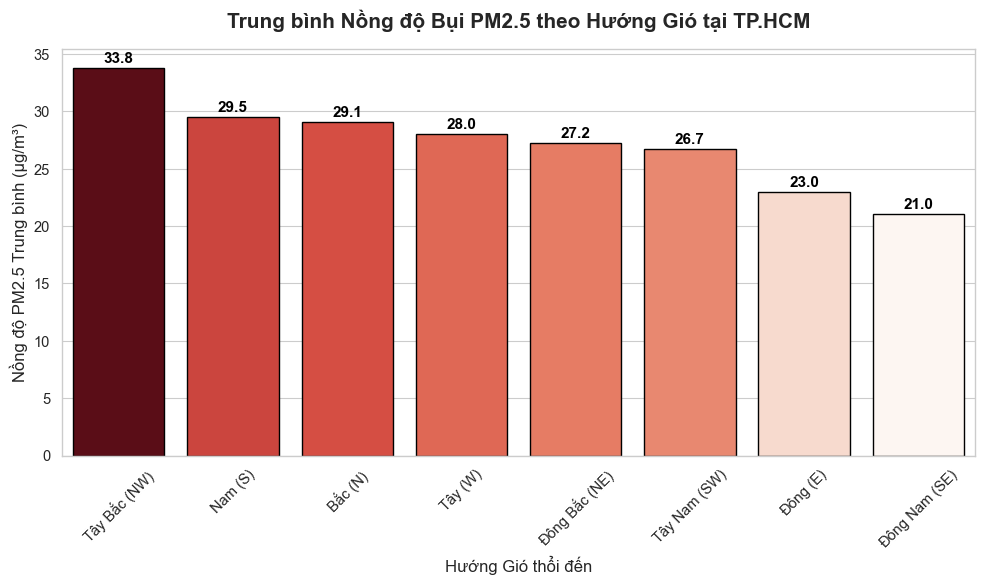

In [8]:
# Hàm chuyển đổi độ (0-360) sang 8 hướng la bàn chuẩn
def degrees_to_compass(d):
    dirs = ['Bắc (N)', 'Đông Bắc (NE)', 'Đông (E)', 'Đông Nam (SE)', 'Nam (S)', 'Tây Nam (SW)', 'Tây (W)', 'Tây Bắc (NW)']
    # Chia 360 độ thành 8 phần (mỗi phần 45 độ)
    ix = int(round(d / (360. / len(dirs))))
    return dirs[ix % len(dirs)]

# Tạo cột hướng gió bằng chữ
df['Wind_Compass'] = df['Wind_Dir'].apply(degrees_to_compass)

# Tính trung bình PM2.5 theo từng hướng gió và sắp xếp giảm dần
wind_stats = df.groupby('Wind_Compass')['PM2.5'].mean().reset_index()
wind_stats = wind_stats.sort_values(by='PM2.5', ascending=False)

# ======================================================================
# VẼ BIỂU ĐỒ BAR CHART
# ======================================================================
plt.figure(figsize=(10, 6))

# Tạo dải màu (Cao nhất là Đỏ đậm, Thấp nhất là Đỏ nhạt)
norm = plt.Normalize(wind_stats['PM2.5'].min(), wind_stats['PM2.5'].max())
colors = plt.cm.Reds(norm(wind_stats['PM2.5']))

# Vẽ biểu đồ cột
sns.barplot(data=wind_stats, x='Wind_Compass', y='PM2.5', palette=colors, edgecolor='black', linewidth=1)

# Ghi trực tiếp con số lên đỉnh mỗi cột
for index, row in enumerate(wind_stats.itertuples()):
    plt.text(index, row._2 + 0.5, f"{row._2:.1f}", color='black', ha="center", fontsize=11, fontweight='bold')

plt.title('Trung bình Nồng độ Bụi PM2.5 theo Hướng Gió tại TP.HCM', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Nồng độ PM2.5 Trung bình (µg/m³)', fontsize=12)
plt.xlabel('Hướng Gió thổi đến', fontsize=12)
plt.xticks(rotation=45) # Xoay chữ ở trục X để không bị đè lên nhau

plt.tight_layout()
plt.show() # Hiện biểu đồ

C:\Users\nguye\AppData\Local\Temp\ipykernel_9940\2643707709.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_pm25.values, y=corr_with_pm25.index,


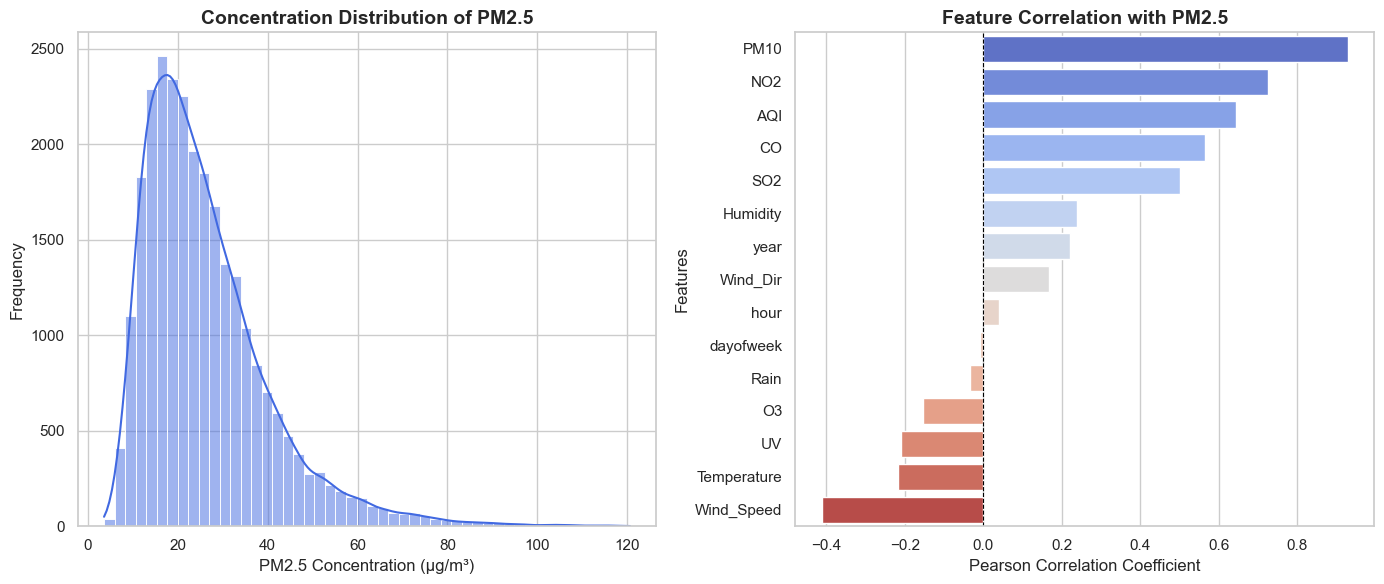

In [12]:
# Thiết lập style cho biểu đồ nhìn học thuật và rõ nét hơn
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Khởi tạo Figure với 2 subplots nằm ngang (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 1. Vẽ biểu đồ phân bố PM2.5 (Distribution)
# ==========================================
# Dùng histplot kết hợp đường mật độ KDE
sns.histplot(df['PM2.5'], bins=50, kde=True, color='royalblue', ax=axes[0])

axes[0].set_title('Concentration Distribution of PM2.5', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PM2.5 Concentration (µg/m³)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# ==========================================
# 2. Vẽ biểu đồ tương quan với PM2.5 (Correlation Bar Chart)
# ==========================================
# Tính ma trận tương quan Pearson, lấy cột PM2.5, bỏ đi chính nó và sắp xếp giảm dần
# Lọc ra chỉ các cột chứa dữ liệu dạng số (loại bỏ các cột text như 'Cuối tuần (T7-CN)')
numeric_df = df.select_dtypes(include=['number'])

# Tính ma trận tương quan Pearson trên tập dữ liệu dạng số
corr_with_pm25 = numeric_df.corr(method='pearson')['PM2.5'].drop('PM2.5').sort_values(ascending=False)
# Sử dụng palette 'coolwarm' để hiển thị dải màu từ xanh (dương) sang đỏ (âm) giống ảnh của bạn
sns.barplot(x=corr_with_pm25.values, y=corr_with_pm25.index, 
            palette='coolwarm', ax=axes[1], orient='h')

axes[1].set_title('Feature Correlation with PM2.5', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient', fontsize=12)
axes[1].set_ylabel('Features', fontsize=12)

# Thêm đường line dọc ở mốc 0 để dễ nhìn phân định âm dương
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

# Tự động căn chỉnh khoảng cách giữa 2 biểu đồ để không bị đè chữ
plt.tight_layout()

# Lưu ảnh chất lượng cao để chèn vào paper (dpi=300 là chuẩn in ấn)
plt.savefig('EDA_PM25_Analysis.png', dpi=300, bbox_inches='tight')

# Hiển thị
plt.show()